<a href="https://colab.research.google.com/github/a23310320-spec/PROYECTO_23310320_23310378_6F/blob/main/PROYECTO_23310320_23310378_6F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# PROYECTO DE VISIÓN ARTIFICIAL: DETECCIÓN DE OBJETOS (PLÁTANOS)
# ASIGNATURA: Visión Artificial / Ingeniería Mecatrónica
# LIBRERÍAS REQUERIDAS: roboflow, ultralytics
# ==============================================================================

# ------------------------------------------------------------------------------
# PASO 1: INSTALACIÓN DE DEPENDENCIAS
# ------------------------------------------------------------------------------
# Se instalan las librerías necesarias en el entorno de ejecución.
# 'roboflow' se encarga de la gestión y descarga del conjunto de datos etiquetado.
# 'ultralytics' proporciona el ecosistema completo para el modelo YOLOv8.
!pip install roboflow

# ------------------------------------------------------------------------------
# PASO 2: CONFIGURACIÓN Y DESCARGA DEL DATASET DESDE ROBOFLOW
# ------------------------------------------------------------------------------
!pip install roboflow
from roboflow import Roboflow
# Inicialización de la API de Roboflow mediante la clave de autenticación del usuario
rf = Roboflow(api_key="Y4GHGbFNRjW9xXjKeaeg")
# Conexión al espacio de trabajo y proyecto específico dentro de la plataforma
project = rf.workspace("comvis-banana").project("comvis-banana-2")
# Selección de la versión del dataset y descarga en formato nativo para YOLOv8.
# Nota: Se utiliza el argumento "yolov8" para asegurar la correcta estructura
# de carpetas (train/val) y la generación del archivo de configuración 'data.yaml'.
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
# ------------------------------------------------------------------------------
# PASO 3: VERIFICACIÓN DEL ENTORNO DE EJECUCIÓN (HARDWARE)
# ------------------------------------------------------------------------------
!pip install ultralytics
import ultralytics
# Ejecuta un diagnóstico del sistema para verificar la disponibilidad de aceleración
# por hardware (GPU CUDA) o si el entrenamiento se realizará mediante procesamiento secuencial (CPU).
ultralytics.checks()

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.3/107.7 GB disk)


In [ ]:
# ------------------------------------------------------------------------------
# PASO 4: CONFIGURACIÓN Y ENTRENAMIENTO DEL MODELO DE VISIÓN
# ------------------------------------------------------------------------------
from ultralytics import YOLO
# Carga de la arquitectura base pre-entrenada YOLOv8 Nano ('yolov8n.pt').
# Se selecciona esta variante por su alta velocidad de procesamiento y ligereza,
# ideal para entornos embebidos y optimización de tiempos por época (epoch).
model = YOLO('yolov8n.pt')
# Inicio del proceso de entrenamiento (Fine-Tuning) adaptado al dataset descargado.
# Parámetros configurados:
# - data: Ruta absoluta o relativa hacia el archivo 'data.yaml' que contiene los paths de las imágenes y nombres de clases.
# - epochs: Número de ciclos completos de entrenamiento sobre el dataset (configurado en 10 para validación rápida).
# - imgsz: Resolución de entrada de las imágenes escalada a 640x640 píxeles.
# - plots: Habilita la generación automática de gráficas de rendimiento (pérdidas, precisión mAP, matriz de confusión).
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,       # 30 vueltas de entrenamiento para empezar
    imgsz=640,       # Tamaño de las imágenes
    plots=True       # Para que nos genere gráficas de rendimiento
)

New https://pypi.org/project/ultralytics/8.4.72 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Comvis-banana-2-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0,

In [ ]:
# ==============================================================================
# DESCARGA DE LA IMAGEN DE EJERCICIO DESDE INTERNET
# ==============================================================================

# Se utiliza el comando 'wget' de Linux para bajar la imagen de plátanos directamente al entorno.
# El parámetro '-nc' (no-clobber) evita volver a descargar el archivo si ya existe en Colab.
# El parámetro '-O' fuerza a que el archivo se guarde exactamente con el nombre asignado al final.
!wget -nc https://www.tasteofhome.com/wp-content/uploads/2023/08/TOHAM22_PU5323_B11_11_10bC-HORIZ.jpg -O TOHAM22_PU5323_B11_11_10bC-HORIZ.jpg

--2026-06-20 02:28:52--  https://www.tasteofhome.com/wp-content/uploads/2023/08/TOHAM22_PU5323_B11_11_10bC-HORIZ.jpg
Resolving www.tasteofhome.com (www.tasteofhome.com)... 104.18.3.91, 104.18.2.91, 2606:4700::6812:25b, ...
Connecting to www.tasteofhome.com (www.tasteofhome.com)|104.18.3.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 144666 (141K) [image/jpeg]
Saving to: ‘TOHAM22_PU5323_B11_11_10bC-HORIZ.jpg’

TOHAM22_PU5323_B11_ 100%[===================>] 141.28K  --.-KB/s    in 0.002s  

2026-06-20 02:28:52 (58.0 MB/s) - ‘TOHAM22_PU5323_B11_11_10bC-HORIZ.jpg’ saved [144666/144666]

Imagen de ejemplo 'banana.jpg' descargada.


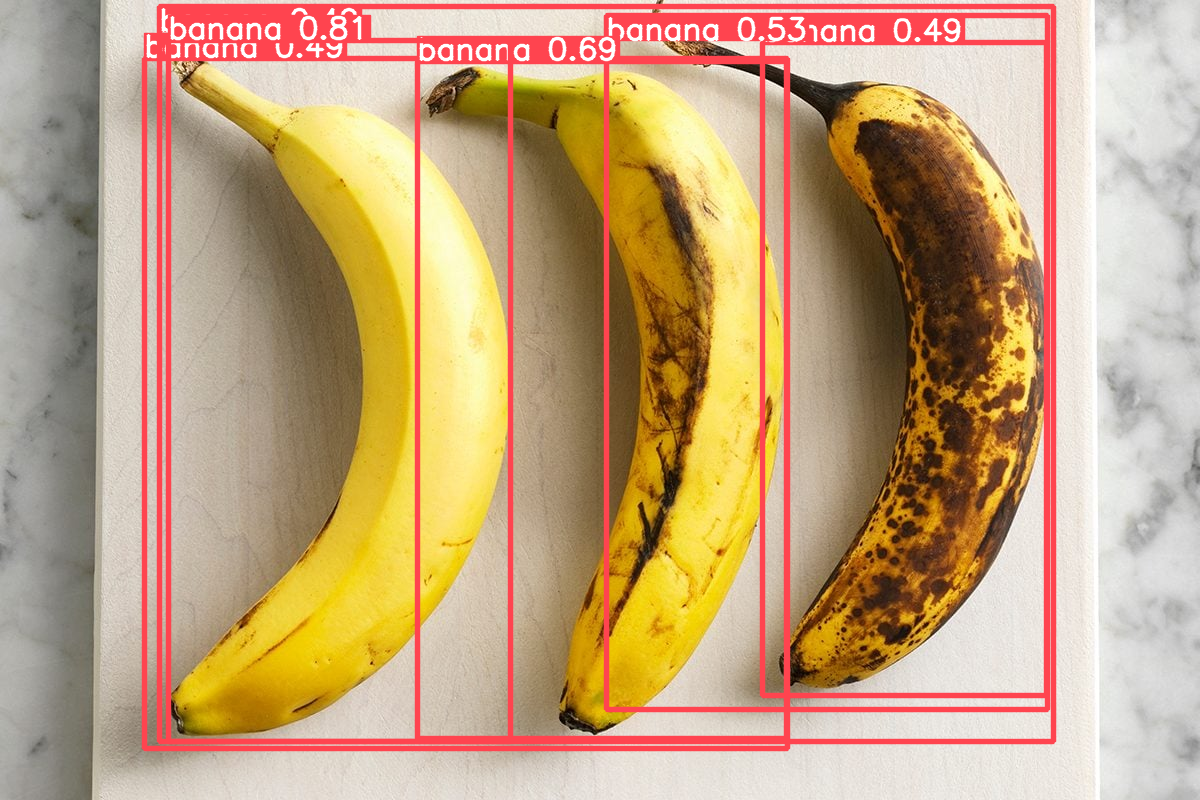

In [ ]:
# ==============================================================================
# EJECUCIÓN DE LA INFERENCIA Y DESPLIEGUE VISUAL
# ==============================================================================

# 1. Realizar la detección de objetos utilizando el modelo cargado
# Se pasa como argumento el nombre de la imagen que descargamos previamente
results = model('TOHAM22_PU5323_B11_11_10bC-HORIZ.jpg')

# 2. Procesar y renderizar los resultados en el cuaderno de Colab
for r in results:
    # Generar un arreglo bidimensional (Numpy array) en formato BGR con las cajas dibujadas
    im_array = r.plot()

    # Invertir los canales de color de BGR a RGB ([..., ::-1]) para que sea compatible con PIL
    im = Image.fromarray(im_array[..., ::-1])

    # Desplegar la imagen de manera nativa e inmediata debajo de esta celda
    display(im)

print("Detección de objetos completada. Las imágenes resultantes se muestran arriba y se guardan en el directorio 'runs'.")
